In [1]:
import matplotlib.pyplot as plt
import cv2

# ColorSpaces

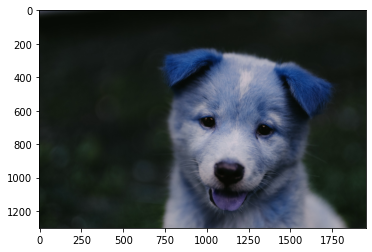

In [13]:
img = cv2.imread('../DATA/00-puppy.jpg')
plt.imshow(img)

### Convert to Different Colorspaces

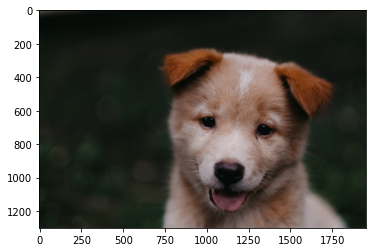

In [14]:
# BGR to RGB
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)

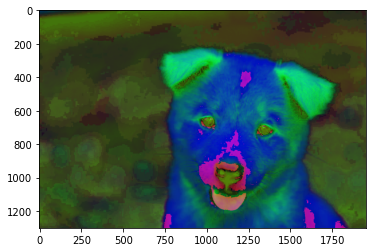

In [6]:
#RGB to HSV

img = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
plt.imshow(img)

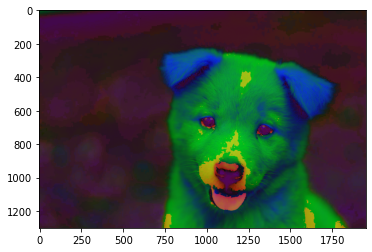

In [15]:
#RGB to HLS

img = cv2.cvtColor(img, cv2.COLOR_RGB2HLS)
plt.imshow(img)

# Blending and Pasting Images

In [17]:
img1 = cv2.imread('../DATA/dog_backpack.png')
img2 = cv2.imread('../DATA/watermark_no_copy.png')

In [18]:
img1.shape

(1401, 934, 3)

In [19]:
img2.shape

(1280, 1277, 3)

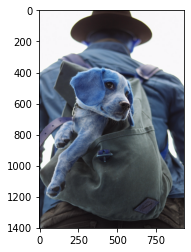

In [20]:
plt.imshow(img1)

In [21]:
img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

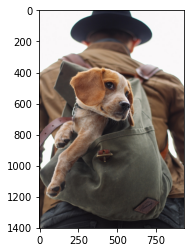

In [22]:
plt.imshow(img1)

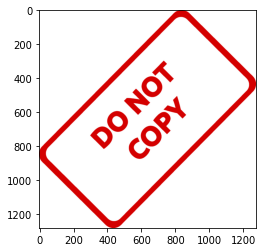

In [23]:
plt.imshow(img2)

In [24]:
# coba blend tanpa resize gambar

blended = cv2.addWeighted(src1=img1, alpha=1, src2=img2, beta=0.3, gamma=0)

error: OpenCV(4.5.5) D:\a\opencv-python\opencv-python\opencv\modules\core\src\arithm.cpp:650: error: (-209:Sizes of input arguments do not match) The operation is neither 'array op array' (where arrays have the same size and the same number of channels), nor 'array op scalar', nor 'scalar op array' in function 'cv::arithm_op'


### Resize the image

In [25]:
img1 = cv2.resize(img1, (1200,1200))
img2 = cv2.resize(img2, (1200,1200))

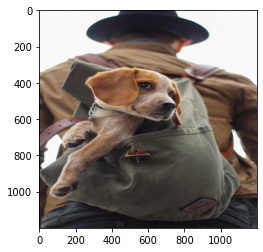

In [26]:
plt.imshow(img1)

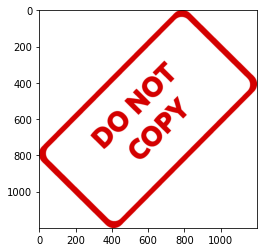

In [27]:
plt.imshow(img2)

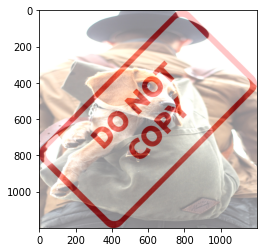

In [43]:
blended = cv2.addWeighted(src1=img1, alpha=0.8, src2=img2, beta=0.5, gamma=0)
plt.imshow(blended)

## Overlaying Images of Different Sizes

In [57]:
#Load ulang gambar

img1 = cv2.imread('../DATA/dog_backpack.png')
img2 = cv2.imread('../DATA/watermark_no_copy.png')

img2 = cv2.resize(img2, (600,600))

In [58]:
img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

In [59]:
large_img = img1
small_img = img2

1. Pilih range of interest (ROI) dengan ukuran sesuai dengan watermark yang akan digunakan
2. Simpan ROI tersebut kedalam var baru
3. Masking
4. Blending watermark dengan ROI
5. Pasting ROI dengan watermark kedalam gambar asli

In [60]:
x_offset = 150
y_offset = 400

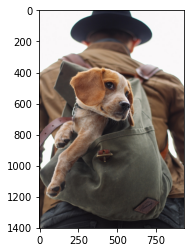

In [63]:
plt.imshow(large_img)

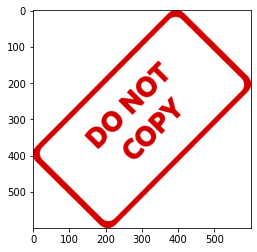

In [62]:
plt.imshow(small_img)

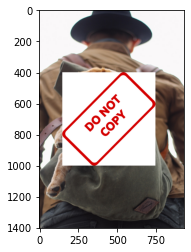

In [64]:
#Insert image

large_img[y_offset:small_img.shape[0]+y_offset, x_offset:small_img.shape[1]+x_offset] = small_img
plt.imshow(large_img)

## Blending Images of Different Sizes

In [65]:
#Load ulang gambar

img1 = cv2.imread('../DATA/dog_backpack.png')
img2 = cv2.imread('../DATA/watermark_no_copy.png')

img2 = cv2.resize(img2, (600,600))

img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

### Create Region of Interest (ROI)

In [66]:
img1.shape

(1401, 934, 3)

In [67]:
#karna akan kita taruh di kanan bawah
x_offset = 934-600
y_offset = 1401-600

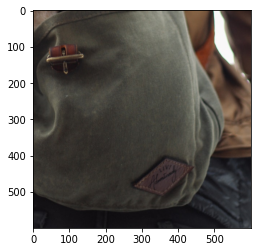

In [69]:
roi = img1[y_offset:1401, x_offset:934]
plt.imshow(roi)

In [70]:
roi.shape

(600, 600, 3)

### Create a Mask

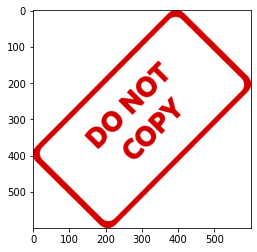

In [71]:
plt.imshow(img2)

In [73]:
img2_gray = cv2.cvtColor(img2, cv2.COLOR_RGB2GRAY)

In [74]:
img2_gray.shape

(600, 600)

In [77]:
img2_gray

array([[255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255]], dtype=uint8)

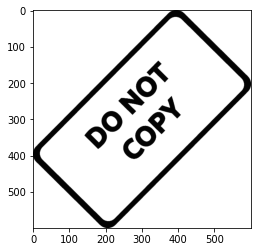

In [79]:
plt.imshow(img2_gray, cmap = 'gray')

In [80]:
#invert nilai / warna nya

mask_inv = cv2.bitwise_not(img2_gray)

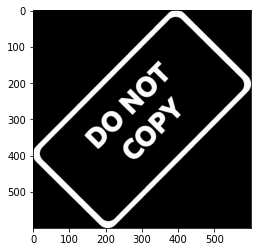

In [82]:
plt.imshow(mask_inv, cmap='gray')

### Convert Mask to have 3 channels

In [83]:
import numpy as np

In [84]:
white_background = np.full(img2.shape, 255, dtype=np.uint8)

In [86]:
white_background.shape

(600, 600, 3)

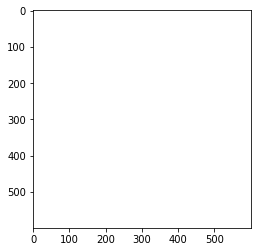

In [88]:
plt.imshow(white_background)

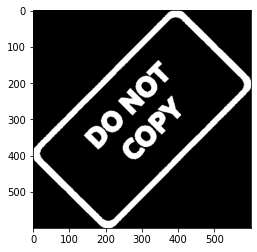

In [89]:
mask_3c = cv2.bitwise_or(white_background, white_background, mask=mask_inv)
plt.imshow(mask_3c)

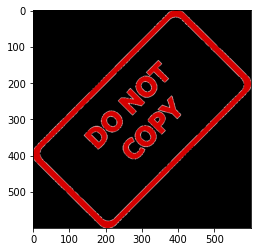

In [91]:
watermark = cv2.bitwise_or(img2, img2, mask=mask_inv)
plt.imshow(watermark)

In [92]:
watermark.shape

(600, 600, 3)

In [93]:
watermark

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8)

## Blend the ROI with watermark

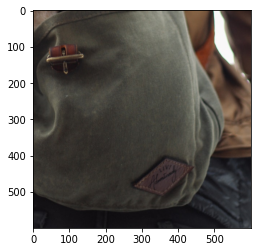

In [94]:
plt.imshow(roi)

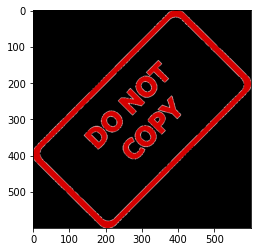

In [95]:
plt.imshow(watermark)

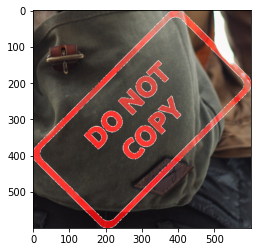

In [97]:
final = cv2.bitwise_or(roi,watermark)
plt.imshow(final)

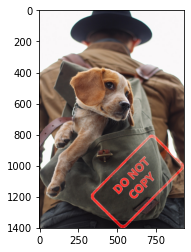

In [99]:
# add to original image

large_img = img1
small_img = final

large_img[y_offset:y_offset+small_img.shape[0] , x_offset:x_offset+small_img.shape[1]] = small_img

plt.imshow(large_img)

# Thresholding

In [100]:
img = cv2.imread('../DATA/rainbow.jpg')

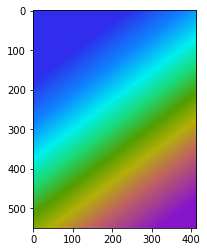

In [101]:
plt.imshow(img)

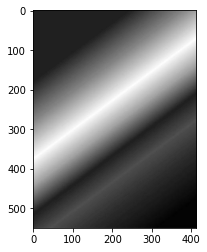

In [105]:
#Load as BW images
img = cv2.imread('../DATA/rainbow.jpg', 0)
plt.imshow(img, cmap='gray')

Different Threshold Types

Binary

In [121]:
ret, thresh1 = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

In [107]:
ret

127.0

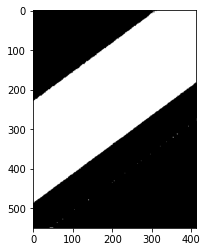

In [122]:
plt.imshow(thresh1, cmap='gray')

Binary Inverse

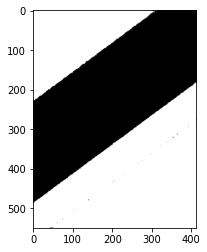

In [123]:
ret, thresh2 = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY_INV)
plt.imshow(thresh2, cmap='gray')

Threshold Truncation

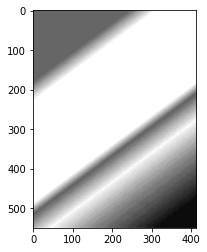

In [124]:
ret, thresh3 = cv2.threshold(img, 127, 255, cv2.THRESH_TRUNC)
plt.imshow(thresh3, cmap='gray')

To Zero

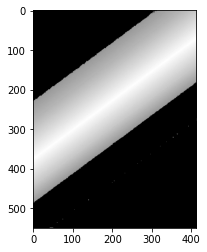

In [125]:
ret, thresh4 = cv2.threshold(img, 127, 255, cv2.THRESH_TOZERO)
plt.imshow(thresh4, cmap='gray')

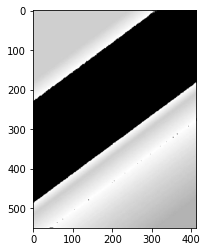

In [126]:
ret, thresh4 = cv2.threshold(img, 127, 255, cv2.THRESH_TOZERO_INV)
plt.imshow(thresh4, cmap='gray')

## Real World Application

Gambar TTS

In [131]:
img = cv2.imread('../DATA/crossword.jpg',0)

In [133]:
#function to display image larger

def showpic(img):
    fig = plt.figure(figsize=(15,15))
    ax = fig.add_subplot(111)
    ax.imshow(img,cmap='gray')

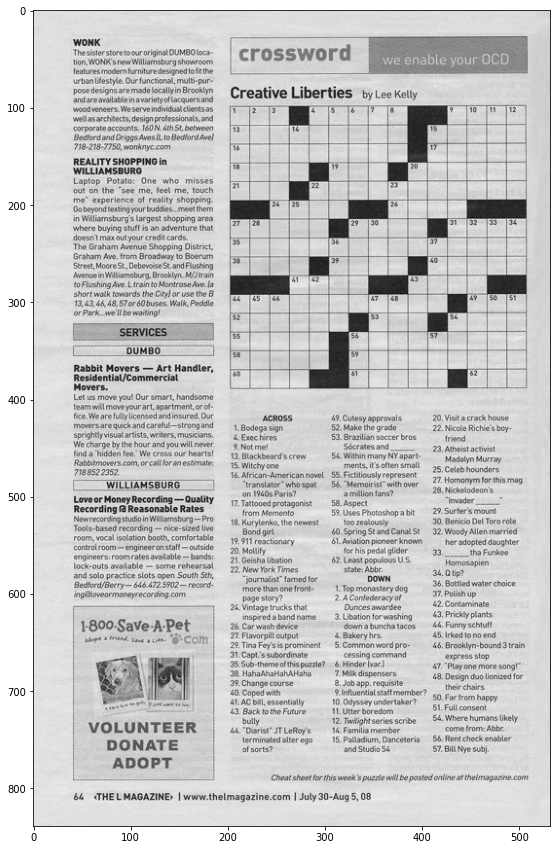

In [134]:
showpic(img)

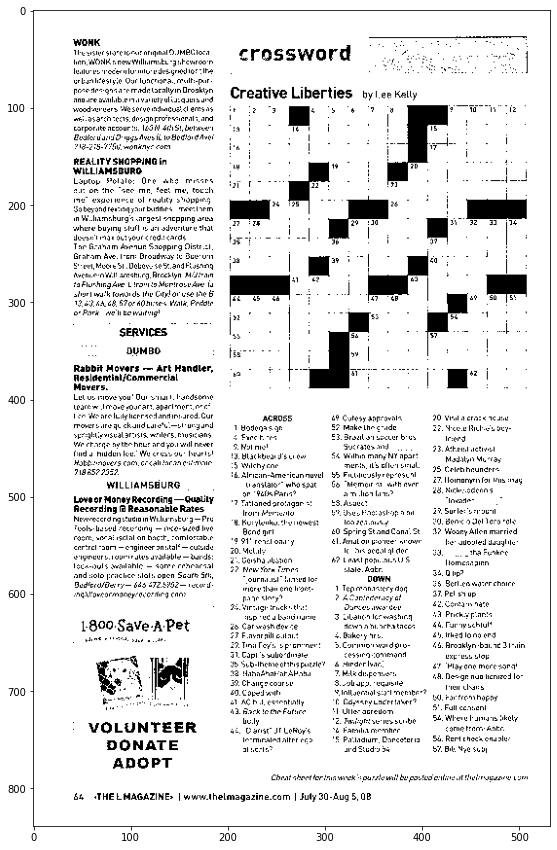

In [138]:
# Simple binary threshold

ret, th1 = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
showpic(th1)

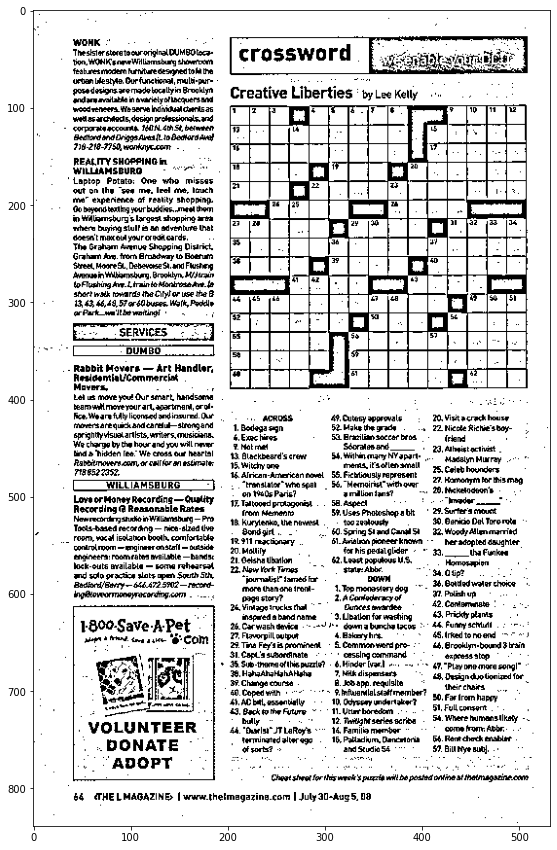

In [147]:
#adaptive trheshold

th2 = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 11, 10)
showpic(th2)

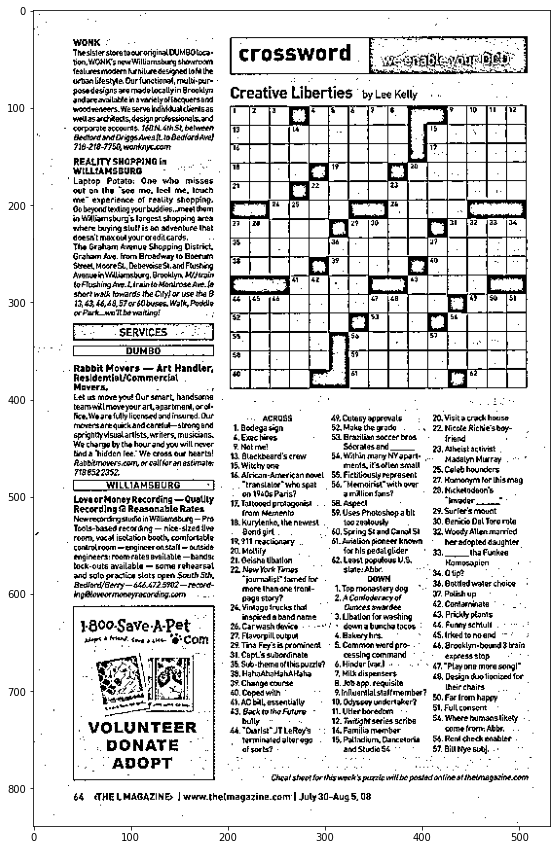

In [149]:
#adaptive trheshold

th3 = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 15, 10)
showpic(th3)

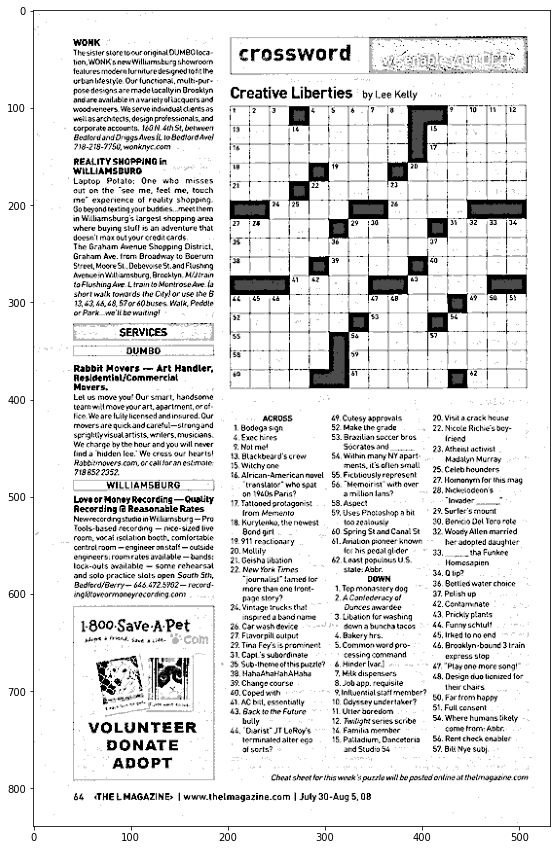

In [150]:
blended = cv2.addWeighted(src1=th1, alpha=0.7, src2=th2, beta=0.3, gamma=0)
showpic(blended)